# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [15]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("airbnb_listings.csv")

# Preview data
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,host_url,host_name,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20250804133828,2025-08-04,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://www.airbnb.com/users/show/4621559,Kenneth,...,4.56,3.22,3.67,NaN,0,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20250804133828,2025-08-04,city scrape,Funky Urban Gem: Prime Central Location - Park...,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://www.airbnb.com/users/show/19648678,Terra,...,4.81,4.81,4.77,NaN,0,4,4,0,0,2.32
2,5651579,https://www.airbnb.com/rooms/5651579,20250804133828,2025-08-04,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://www.airbnb.com/users/show/29288920,Gregg,...,4.88,4.76,4.64,NaN,0,2,1,1,0,2.97
3,6623339,https://www.airbnb.com/rooms/6623339,20250804133828,2025-08-04,city scrape,Bright & Cozy City Stay · Top Location + Parking!,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://www.airbnb.com/users/show/19648678,Terra,...,4.70,4.80,4.72,NaN,0,4,4,0,0,2.68
4,9005989,https://www.airbnb.com/rooms/9005989,20250804133828,2025-08-04,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://www.airbnb.com/users/show/17766924,Sugey,...,4.93,4.87,4.77,NaN,0,1,1,0,0,5.67


## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

### In Your Response:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?



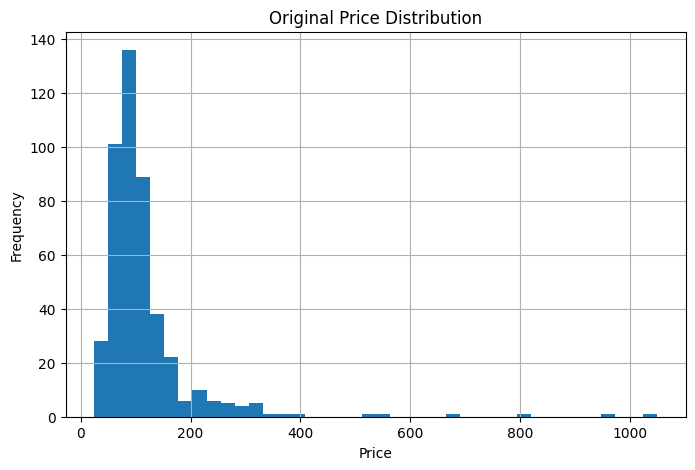

Skewness: 5.454774817581612


In [16]:
# Clean price column if it contains $ or commas
if df["price"].dtype == "object":
    df["price"] = (
        df["price"]
        .astype(str)
        .str.replace(r"[\$,]", "", regex=True)
    )
    df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Plot original distribution
plt.figure(figsize=(8,5))
df["price"].dropna().hist(bins=40)
plt.title("Original Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Print skew value
print("Skewness:", df["price"].skew())

### ✍️ Your Response: 🔧
1.

2.

3.

## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

### In Your Response:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

In [17]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# --- Choose two numeric columns ---
minmax_col = "availability_365"   # typically 0–365
zscore_col = "minimum_nights"     # can vary widely

# --- Make sure they exist and are numeric ---
for col in [minmax_col, zscore_col]:
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found. Available columns: {list(df.columns)}")
    df[col] = pd.to_numeric(df[col], errors="coerce")

# --- Min-Max scaling (0 to 1) ---
mm = MinMaxScaler()
df[f"{minmax_col}_minmax"] = mm.fit_transform(df[[minmax_col]])

# --- Z-score standardization (mean 0, std 1) ---
ss = StandardScaler()
df[f"{zscore_col}_zscore"] = ss.fit_transform(df[[zscore_col]])

# Quick sanity check
df[[minmax_col, f"{minmax_col}_minmax", zscore_col, f"{zscore_col}_zscore"]].head()


,availability_365,availability_365_minmax,minimum_nights,minimum_nights_zscore
0,126,0.345205,28,1.068715
1,337,0.923288,2,-0.237784
2,39,0.106849,2,-0.237784
3,338,0.926027,2,-0.237784
4,184,0.504110,1,-0.288034


### ✍️ Your Response: 🔧
1. Columns + methods: I scaled availability_365 using Min-Max scaling (0–1) and minimum_nights using Z-score standardization (mean 0, standard deviation 1).

2. When scaled values help: Scaled values are useful when comparing variables with very different ranges or feeding them into models where scale can affect results (e.g., distance-based methods, regularized regression, clustering).

3. Who benefits and why: Airbnb data analysts and data scientists benefit for modeling and segmentation, while product teams benefit because scaled features make metrics easier to combine into scoring systems (e.g., “availability score” + “stay-length score”).

## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

### In Your Response:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?


In [18]:
# Choose a numeric column to group
group_col = "number_of_reviews"

if group_col not in df.columns:
    raise KeyError(f"Column '{group_col}' not found. Available columns: {list(df.columns)}")

df[group_col] = pd.to_numeric(df[group_col], errors="coerce")

# Create 3 bins using quantiles: Low / Medium / High
df["review_volume_level"] = pd.qcut(df[group_col], q=3, labels=["Low", "Medium", "High"])

# Check results
df[[group_col, "review_volume_level"]].head(), df["review_volume_level"].value_counts(dropna=False)

(   number_of_reviews review_volume_level
 0                  9              Medium
 1                310                High
 2                371                High
 3                332                High
 4                621                High,
 review_volume_level
 Medium    156
 Low       155
 High      148
 Name: count, dtype: int64)

### ✍️ Your Response: 🔧
What I grouped: I grouped number_of_reviews into 3 categories: Low, Medium, High.

Why grouped view is preferred: A grouped view makes segmentation and communication easier—stakeholders often don’t need exact review counts, they need clear buckets for decision-making.

Who this helps: This helps marketing teams (segment listings by engagement), city partners (understand areas with high tourist activity), and host success teams (identify listings that may need help generating traction).

## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

### In Your Response:
1. What two new columns did you create?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

In [19]:
# Ensure needed columns exist
needed_cols = ["price", "accommodates", "minimum_nights"]
for col in needed_cols:
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found. Available columns: {list(df.columns)}")

# Make numeric
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["accommodates"] = pd.to_numeric(df["accommodates"], errors="coerce")
df["minimum_nights"] = pd.to_numeric(df["minimum_nights"], errors="coerce")

# 1) Ratio feature: price per person (avoid divide by zero)
df["price_per_person"] = df["price"] / df["accommodates"].replace(0, np.nan)

# 2) Flag feature: long-stay friendly (28+ nights)
df["long_stay_friendly"] = (df["minimum_nights"] >= 28).astype(int)

df[["price", "accommodates", "price_per_person", "minimum_nights", "long_stay_friendly"]].head()

,price,accommodates,price_per_person,minimum_nights,long_stay_friendly
0,70.0,4,17.5,28,1
1,104.0,2,52.0,2,0
2,75.0,2,37.5,2,0
3,101.0,2,50.5,2,0
4,110.0,4,27.5,1,0


### ✍️ Your Response: 🔧 🔧
New columns created: I created price_per_person (price divided by accommodates) and long_stay_friendly (1 if minimum nights ≥ 28, else 0).

Who would use them: Hosts and pricing analysts could use price_per_person to compare value across listings, and product/market teams could use long_stay_friendly to identify inventory suited for monthly stays.

How it helps decisions: price_per_person supports fair comparisons across different-sized homes, and long_stay_friendly helps target the right guest segments (e.g., travel nurses, remote workers) and build filters or promotions.


## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

### ✍️ In your markdown:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?



In [20]:
cat_col = "room_type"

if cat_col not in df.columns:
    raise KeyError(f"Column '{cat_col}' not found. Available columns: {list(df.columns)}")

# One-hot encode and add to df
room_dummies = pd.get_dummies(df[cat_col], prefix=cat_col, dummy_na=True)
df = pd.concat([df, room_dummies], axis=1)

df[[cat_col] + list(room_dummies.columns)].head()

,room_type,room_type_Entire home/apt,room_type_Private room,room_type_nan
0,Entire home/apt,True,False,False
1,Entire home/apt,True,False,False
2,Entire home/apt,True,False,False
3,Entire home/apt,True,False,False
4,Entire home/apt,True,False,False


### ✍️ Your Response: 🔧
What I encoded and why: I encoded room_type because it’s categorical and models/dashboards need numeric inputs to compare groups reliably.

Encoding method: I used one-hot encoding since room types are nominal (no ranking like “low/medium/high”).

How this helps: One-hot encoded room types can improve a pricing model by letting it learn price differences across room categories, and it helps dashboards by enabling easy filtering and comparison of listing performance by room type.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [21]:
# Optional: remove obvious duplicate columns or columns that are completely empty
# (safe cleanup step)
df = df.dropna(axis=1, how="all")

# Export
df.to_csv("cleaned_airbnb_data_7.csv", index=False)

print("Saved: cleaned_airbnb_data_7.csv")
print("Rows, Columns:", df.shape)

Saved: cleaned_airbnb_data_7.csv
Rows, Columns: (459, 84)


## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### In Your Response:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. Most important/interesting step: The most important transformation was the log transformation on price, because it made the distribution easier to interpret and prevented a small number of luxury listings from dominating the analysis.

2. Most useful change for stakeholders: For a host, the most useful feature is price_per_person because it helps benchmark pricing fairly. For an analyst, scaling and one-hot encoding are most useful because they prepare the data for modeling. For a city planner, review volume categories (Low/Medium/High) help quickly understand engagement patterns across areas.

3. Next step for a dashboard/tool: Next I would build a dashboard that lets users filter by room type, review-volume category, and long-stay friendliness, and then compare median price, occupancy proxies (availability), and review activity by neighborhood.

4. Connection to customized learning outcome: This relates to my learning outcome because it demonstrates transforming real-world data into features that support decision-making (pricing, segmentation, and forecasting) and makes the dataset ready for modeling and business reporting


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [22]:
!jupyter nbconvert --to html "assignment_07_data_transformation.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_07_data_transformation.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_y